<a href="https://colab.research.google.com/github/maellisrll-ui/Python-class-Session4-individual-project/blob/main/Individual_Project_Maellis_RLL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


#                          **INDIVIDUAL PROJECT**

## DATA EXPLORATION AND VISUALIZATION WITH PANDAS & MATPLOTLIB / SEABORN

Student Name : Maëllis Rivoallon Le Lous

Class : 4A DSBI PGE - Python for Data Science


# 🪐  **INTRODUCTION**

The following project aims to analyse a dataset about the Near-Earth Asteroids.

I've chosen this subject because I'm passionate about astrophysics and analysing the asteroids around the Earth seemed intersting.

With this project, I aim to understand better the different variables affecting the asteroids' classification, while also exercising myself with Python.
I wanted to see what were the factors influencing a possible collision of an asteroid with out planet.

The dataset comes from Kaggle, it is available on the following website : https://www.kaggle.com/datasets/darkmatternet/nasa-near-earth-asteroids-and-close-approaches$0


## Part 0 : Import

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 🪐 **DATASET DESCRIPTION**

## Part 1 : Dataset Selection

The dataset that I've chosen is the NASA Near-Earth Asteriods & Close Approaches. I've selected the file gathering the information for 2025, because it contained no duplicated values, while the second file contained only half of its value as unique, because it gathers the value of the year 2015 and the year 2035.

My set contains more than 41'281 rows and 31 columns.
It contains 3 booleans, 20 floats, 1 integer, 1 category and 6 objects. In other words, there are about 10 qualitative variables and 21 quantitatives.

During the data preparation step, I've noticed that some columns contained missing values. Among those, 3 columns contained more than 30'000 missing values minimum, therefore I removed them. I've decided to put this limit of 30'000 because they were the only variables with such an important ratio of missing data. There remaining missing values were divided among 8 columns, which each contained less than 500 missing values. I've estimated that this number was acceptable relatively to the overall number of values. Therefore, I've decided to fill those missing values with their mean, since they were all numerical.

The data contains no duplicated values.

Additionnaly, I've decided to rename several columns, to understand and represent the data better and more clearly.

Some jargon terms include :
*  pha : Potentially Hasardous Asteroid, which
*  albedo : surface reflectivity
*  perihelion : the closest point to the sun during the asteroid's orbit
*  aphelion : the farthest point to the sun during the asteroid's orbit
*  moid : Minimal Orbit Intersection Distance
*  arc : lenght of time during which the asteroid was visible


I've also added 3 new variables that I've found particularly interesting:

1.   The estimation of danger per asteroid, in order to be able to rank the different asteroid that could intersect with out planet compared to their sieze, to estimate their danger.
2.   The number of sight per quality of the orbit, in order to assess if the number of times we saw the asteroid is influenced by its orbit quality.
3.   The number of rotation per orbit, in order to assess how many times the asteroid rotate on itself while making one orbitation around the Earth



In [ ]:
import kagglehub
path = kagglehub.dataset_download("darkmatternet/nasa-near-earth-asteroids-and-close-approaches")

Using Colab cache for faster access to the 'nasa-near-earth-asteroids-and-close-approaches' dataset.


In [ ]:
import os
print (path)
print(os.listdir(path))

/kaggle/input/nasa-near-earth-asteroids-and-close-approaches
['near_earth_asteroids_2025 (1).csv', 'asteroid_close_approaches_2015_2035 (1).csv']


## Part 2 : Data Preparation (Pandas)
We have 2 datasets in our files : the data from 2025 and the data from 2015 and 2035.

For this part, I would like to work on the 2025 dataset because it contains more rows : 41'281.

In [ ]:
df = pd.read_csv(path + "/near_earth_asteroids_2025 (1).csv")

# displaying the structure

df.head()
df.info()


# handling missing values
df.isnull().sum()
  # we have a lot of missing values in the columns : name, albedo, and rot_per.
  # we have some missing values in the columns : H, moid_au, moid_km, moid_lunar_distances, condition_code, first_obs, data_arc, and data_arc_years.

    # we will remove the 3 columns containing a lot of missing values : name, albedo, and rot_per.
df = df.drop(columns=["name"])
df = df.drop(columns=["albedo"])
df = df.drop(columns=["rot_per"])
df.columns

    # The 'first_obs' column is needed for later steps, so we will not drop it here.

    # we will fill the 8 columns containing some missing values with their means : H, moid_au, moid_km, moid_lunar_distances, condition_code, data_arc, and data_arc_years. (<500)
df["H"] = df["H"].fillna(df["H"].mean())
df["moid_au"] = df["moid_au"].fillna(df["moid_au"].mean())
df["moid_km"] = df["moid_km"].fillna(df["moid_km"].mean())
df["moid_lunar_distances"] = df["moid_lunar_distances"].fillna(df["moid_lunar_distances"].mean())
df["condition_code"] = df["condition_code"].fillna(df["condition_code"].mean())
df["data_arc"] = df["data_arc"].fillna(df["data_arc"].mean())
df["data_arc_years"] = df["data_arc_years"].fillna(df["data_arc_years"].mean())
df.columns

# removing duplicates
df.duplicated().sum()
  # There are no duplicated value.


# renaming columns
  # After reading the definitions of the columns on Kaggle, I would like to rename the columns H by magnitude, e by eccentricity, a by aphelion, i by inclinitionation_deg, q by perihelion, n by observation_numbers, per by rotation_period_h, and per_y by orbital_period_year.
df = df.rename(columns={"H": "magnitude"})
df = df.rename(columns={"e": "eccentricity"})
df = df.rename(columns={"a": "aphelion"})
df = df.rename(columns={"i": "inclination_deg"})
df = df.rename(columns={"q": "perihelion"})
df = df.rename(columns={"n": "observation_numbers"})
df = df.rename(columns={"per": "rotation_period_h"})
df = df.rename(columns={"per_y": "orbital_period"})
df.columns

# creating new calculated column :
  # The first calculation I want to add is my estimation of danger per asteroid : distance_per_size = moid_km / diameter_km (moid is the Minimum Orbit Intersection)
  # The objective of this new cell is to be able to rank the different asteroid that could intersect with out planet compared to their sieze, to estimate their danger.
df["distance_per_size"] = df["moid_km"] / df["diameter_km"]

# creating new calculated column :
  # The second calculation I want to add is : numbersight_per_quality : observation_numbers / condition_code
  # The objective of this new cell is to assess if the number of times we saw the asteroid is influenced by its orbit quality
df["numbersight_per_quality"] = df["observation_numbers"] / df["condition_code"]

# creating new calculated column :
  # The third calculation I want to add is : rotation_per_orbit = rotation_period_h / orbital_period_year
  # The objective of this new cell is to assess how many times the asteroid rotate on itself while making one orbitation around the Earth
df["rotation_per_orbit"] = df["rotation_period_h"] / df["orbital_period"]


# generate summary statistcs :
df.describe()

/tmp/ipykernel_3220/1011725067.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path + "/near_earth_asteroids_2025 (1).csv")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41281 entries, 0 to 41280
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   spkid                  41281 non-null  int64  
 1   full_name              41281 non-null  object 
 2   pdes                   41281 non-null  object 
 3   name                   182 non-null    object 
 4   pha                    41281 non-null  bool   
 5   H                      41279 non-null  float64
 6   diameter_km            41281 non-null  float64
 7   diameter_m             41281 non-null  float64
 8   diameter_is_estimated  41281 non-null  bool   
 9   size_category          41281 non-null  object 
 10  albedo                 1204 non-null   float64
 11  rot_per                2181 non-null   float64
 12  class                  41281 non-null  object 
 13  e                      41281 non-null  float64
 14  a                      41281 non-null  float64
 15  i 

,spkid,magnitude,diameter_km,diameter_m,eccentricity,aphelion,inclination_deg,perihelion,ad,rotation_period_h,...,moid_au,moid_km,moid_lunar_distances,observation_numbers,condition_code,data_arc,data_arc_years,distance_per_size,numbersight_per_quality,rotation_per_orbit
count,4.128100e+04,41281.000000,41281.000000,41281.000000,41281.000000,41281.000000,41281.000000,41281.000000,41281.000000,4.128100e+04,...,4.128100e+04,4.128100e+04,41281.000000,41281.000000,41281.000000,41281.000000,41281.000000,4.128100e+04,4.128100e+04,41281.000000
mean,2.852738e+07,23.718323,0.165592,165.588917,0.434323,1.757387,11.834802,0.914116,2.600654,9.706043e+02,...,8.217933e-02,1.229385e+07,31.981713,0.530476,5.262506,1404.433394,3.845177,1.472326e+08,inf,365.246102
std,2.428187e+07,2.876692,0.403793,403.794103,0.176975,2.119936,10.549392,0.221873,4.221280,1.262065e+04,...,9.622907e-02,1.439566e+07,37.449456,0.284677,3.169858,3083.747495,8.442810,2.943278e+08,NaN,0.739750
min,3.002856e+06,9.170000,0.000475,0.500000,0.002800,0.461800,0.010000,0.069000,0.650000,1.150000e+02,...,4.540000e-07,6.800000e+01,0.000000,0.000150,0.000000,0.000000,0.000000,8.819130e+03,2.505000e-05,362.989324
25%,3.745029e+06,21.680000,0.024573,24.600000,0.300300,1.287000,4.350000,0.792000,1.650000,5.330000e+02,...,1.160000e-02,1.735335e+06,4.510000,0.309600,2.000000,6.000000,0.020000,3.459818e+07,5.126667e-02,364.705882
50%,2.046734e+07,24.040000,0.055266,55.300000,0.448200,1.679000,8.400000,0.962000,2.410000,7.950000e+02,...,4.260000e-02,6.372869e+06,16.580000,0.453000,7.000000,23.000000,0.060000,9.114586e+07,8.530000e-02,365.248227
75%,5.433661e+07,25.800000,0.165372,165.400000,0.563000,2.164000,16.550000,1.057000,3.340000,1.160000e+03,...,1.200000e-01,1.795174e+07,46.700000,0.675200,8.000000,1094.000000,3.000000,1.984549e+08,2.955000e-01,365.771812
max,5.460683e+07,34.370000,37.675000,37675.000000,0.996400,350.300000,165.600000,1.300000,699.320000,2.390000e+06,...,7.080000e-01,1.059153e+08,275.530000,3.141000,9.000000,46582.000000,127.530000,2.589567e+10,inf,367.491166


# 🪐  **METHODOLOGY**

To analyse the relationship between the dangerousity of an asteroid and the different variables, I've selected 6 questions.

To answer those questions, I've defined the code for each, then plotted the results in order to increase the visbility of my results.

The questions studied the correlation between all the variables, and the relationship between the most interesting ones. Additionnaly, I've pointed out which asteroids are the largest, the smallest, and the average size. This enabled me to determine the outliers and the distribution of those spatial objects.

There are 7 graphics, regroupping a scatter plot, two histograms, a heatmap, a boxplot, a barplot, a line graph. Each of them were selected depending on the nature of the question, in order to display the answer in the most visible way.

After coding the answer to my questions and the graphs, each time, I wrote some analysis and tried to answer the questions.

## Part 3 and 4 : Data Analysis and Visualisation

**Question 1 : Is there a correlation between the diameter of the asteroids and the duration of their arc around the Earth ?**

                diameter_km  data_arc_years
diameter_km        1.000000        0.615755
data_arc_years     0.615755        1.000000


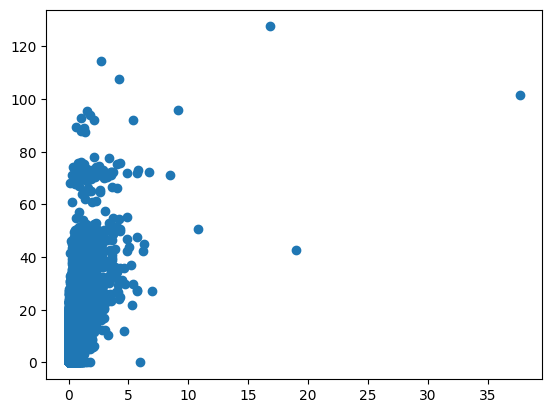

In [ ]:
corr = df[["diameter_km", "data_arc_years"]].corr()

print(corr)

plt.scatter(x=df["diameter_km"], y=df["data_arc_years"])
plt.show()


To answer our question, we have a correlation of 0.616, which means that there is a correlation positive moderate. It means that as the diameter of the asteroid increases, the duration of their arc around Earth is greater.
In other words, the bigger the asteroid, the more visible it is.

Concerning our scatter plot, we can see that the points are all concentrated in the same area and that they tend to move on the y axis rather than the x axis. It means that most of the asteroids have a small diameter. However, I think that the dispersion is quite big along the y-axis. Therefore, the diameter is not the only variable associated to the duration of the visibility of an asteroid.

We can see some outliers that confirm our analysis : for example an asteroid with a diameter of 18 km is visible for a longer period of time than an asteroid with a 38 km diameter.

----


**Question 2 : What are the 5 asteroids that come the closest to Earth ?**

In [ ]:
df.nsmallest(10,"moid_km")

,spkid,full_name,pdes,pha,magnitude,diameter_km,diameter_m,diameter_is_estimated,size_category,class,...,moid_km,moid_lunar_distances,observation_numbers,condition_code,last_obs,data_arc,data_arc_years,distance_per_size,numbersight_per_quality,rotation_per_orbit
11041,3655730,(2014 AA),2014 AA,False,30.95,0.002293,2.3,True,Tiny (<25m) — Airburst/harmless,APO,...,68.0,0.0,0.78730,9.0,2014-01-02,1.000000,0.000000,29651.587488,0.087478,365.600000
40193,54564988,(2025 WP16),2025 WP16,False,28.89,0.005922,5.9,True,Tiny (<25m) — Airburst/harmless,APO,...,131.0,0.0,0.52280,7.0,2025-12-02,4.000000,0.010000,22121.284059,0.074686,364.550265
36527,54496614,(2024 UG9),2024 UG9,False,32.61,0.001068,1.1,True,Tiny (<25m) — Airburst/harmless,APO,...,181.0,0.0,0.09783,6.0,2024-10-30,1404.433394,3.845177,169518.699436,0.016305,364.356436
14831,3753854,(2016 LE10),2016 LE10,False,27.10,0.013504,13.5,True,Tiny (<25m) — Airburst/harmless,APO,...,293.0,0.0,0.26180,7.0,2016-06-09,1.000000,0.000000,21697.348132,0.037400,364.361702
37725,54520534,(2025 DZ4),2025 DZ4,False,27.25,0.012603,12.6,True,Tiny (<25m) — Airburst/harmless,APO,...,438.0,0.0,0.50730,8.0,2025-02-24,1.000000,0.000000,34754.668257,0.063412,365.979381
18340,3802441,(2018 GD2),2018 GD2,False,29.50,0.004472,4.5,True,Tiny (<25m) — Airburst/harmless,APO,...,527.0,0.0,0.94200,6.0,2018-04-12,2.000000,0.010000,117855.445025,0.157000,363.809524
28494,54246392,(2022 CJ5),2022 CJ5,False,30.30,0.003094,3.1,True,Tiny (<25m) — Airburst/harmless,APO,...,613.0,0.0,0.55120,6.0,2022-02-10,1.000000,0.000000,198152.479657,0.091867,364.804469
14281,3748229,(2016 DA31),2016 DA31,False,29.90,0.003719,3.7,True,Tiny (<25m) — Airburst/harmless,APO,...,651.0,0.0,0.68860,8.0,2016-02-29,1.000000,0.000000,175033.035857,0.086075,365.734266
36361,54494469,(2024 UQ),2024 UQ,False,32.66,0.001043,1.0,True,Tiny (<25m) — Airburst/harmless,APO,...,850.0,0.0,0.30870,7.0,2024-10-22,1404.433394,3.845177,814625.428808,0.044100,366.771160
16807,3780735,(2017 QT1),2017 QT1,False,26.70,0.016235,16.2,True,Tiny (<25m) — Airburst/harmless,APO,...,884.0,0.0,0.24710,8.0,2017-08-19,4.000000,0.010000,54449.174760,0.030887,365.914787


It is interesting to see that in 2014, we had an asteroid that came as close as only 68km of our planet.

In 2025, we had another that came as close as 131 km from the Earth.

(MOID = Minimal Orbital Intersection Distance)

Text(0.5, 1.0, 'Distribution of the Distance of the Asteroids from Earth')

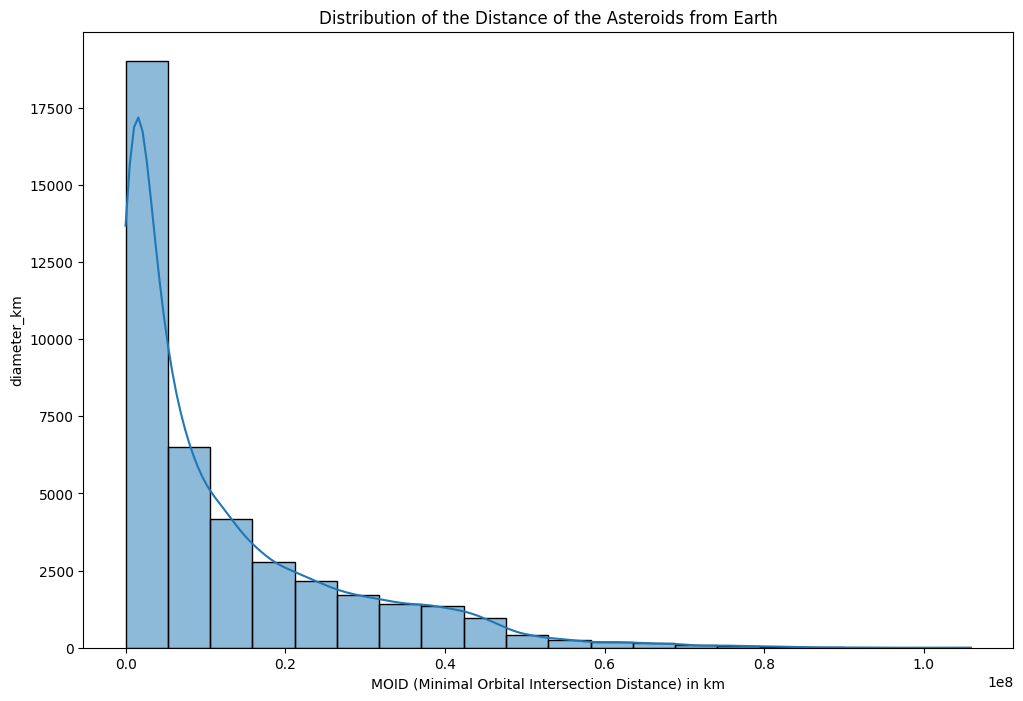

In [ ]:
#Let's show the diameter of the asteroid in relation to the moid_km with an histogram

plt.figure(figsize=(12, 8))
sns.histplot(df["moid_km"], bins=20, kde=True)
plt.xlabel('MOID (Minimal Orbital Intersection Distance) in km')
plt.ylabel('diameter_km')
plt.title('Distribution of the Distance of the Asteroids from Earth')


It is reassuring to see that the smallest asteroids are the one that come the closest to the Earth !

----

**Question 3 : Which variables are the most correlated ?** using a heatmap

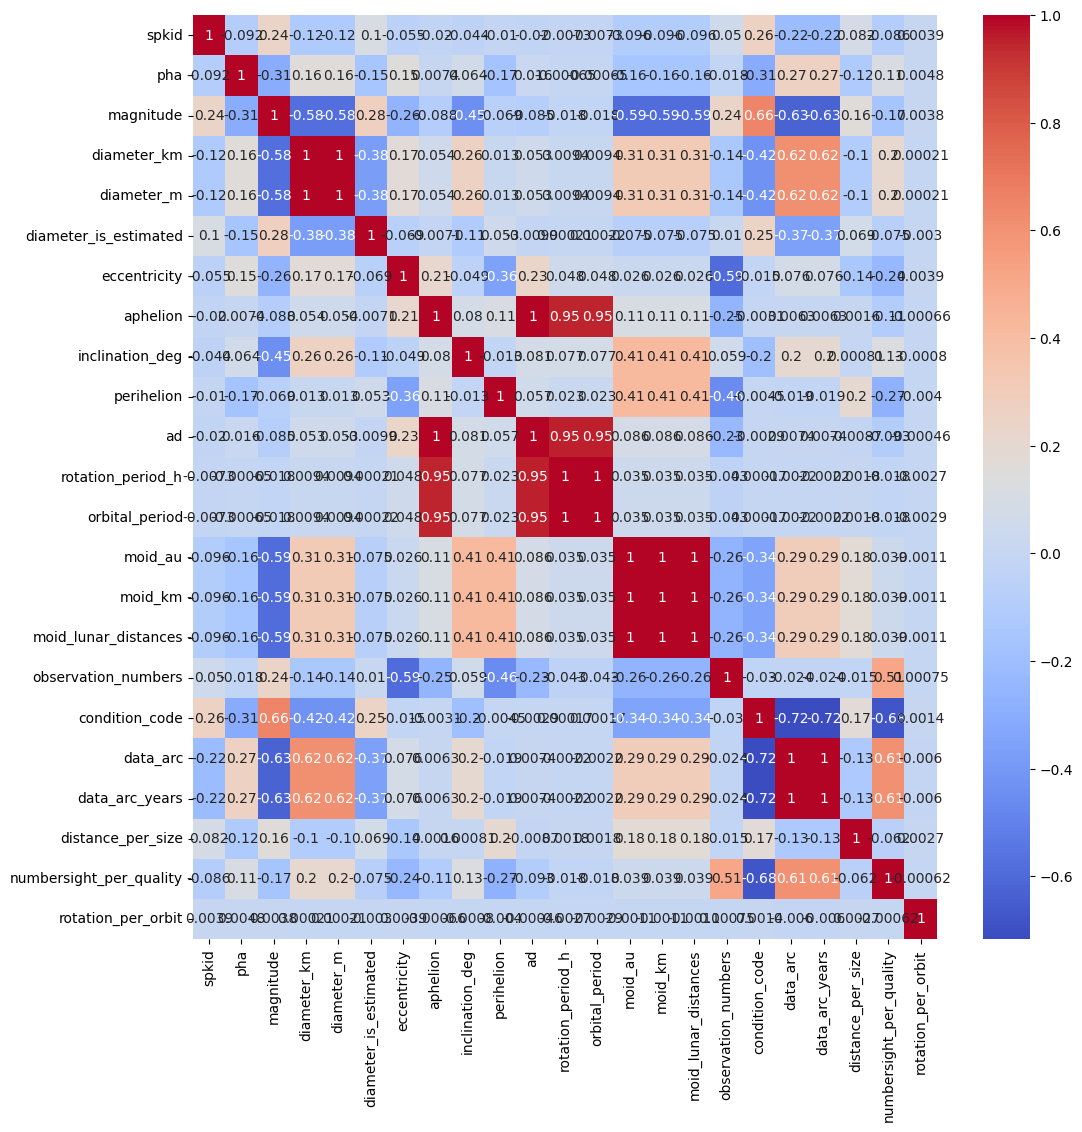

In [ ]:
plt.figure(figsize=(12,12))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")
plt.show()

We see without suspense that we have a warm line in the middle as it corresponds to the variable being perfectly correlated with themselves, and their related variables (for example, moid_km and moid_au, which basicaly show the same thing with different units)

Close to 1, we find the rotation period or orbital period with the aphelion. It shows that the asteroids with larger apheloin generally have a longer orbital and rotation period. (Aphelion is the farthest point from the Sun during their rotation around our star).

Another interesting correlation is the diameter and the data_arc, which we've analysed at question 1.



What is surprising is to see that we have some variables that are greatly inversely correlated between each other. We can find the relationship between the condition code and the data_arc, which is characterised with a correlation of -0.72, negative moderate. It means that the asteroids that we've seen the less, are the ones with the most unpredictable orbits. In other words, the visibility of an asteroid is inversely related to the level its orbit unpredictability.

----

**Question 4 : What is the average asteroid size ? What is the smallest one  and the largest one's diameter ?**

In [ ]:
np.mean(df["diameter_km"])

np.float64(0.16559206352728661)

In [ ]:
df.nsmallest(1,"diameter_km")


,spkid,full_name,pdes,pha,magnitude,diameter_km,diameter_m,diameter_is_estimated,size_category,class,...,moid_km,moid_lunar_distances,observation_numbers,condition_code,last_obs,data_arc,data_arc_years,distance_per_size,numbersight_per_quality,rotation_per_orbit
12862,54510130,(2015 FF415),2015 FF415,False,34.37,0.000475,0.5,True,Tiny (<25m) — Airburst/harmless,APO,...,1.229385e+07,31.981713,0.9727,8.0,2015-03-22,0.0,0.0,2.589567e+10,0.121588,366.336634


In [ ]:
df.nlargest(1,"diameter_km")

,spkid,full_name,pdes,pha,magnitude,diameter_km,diameter_m,diameter_is_estimated,size_category,class,...,moid_km,moid_lunar_distances,observation_numbers,condition_code,last_obs,data_arc,data_arc_years,distance_per_size,numbersight_per_quality,rotation_per_orbit
3,20001036,1036 Ganymed (A924 UB),1036,False,9.17,37.675,37675.0,False,Large (>1 km) — City killer+,AMO,...,51312070.0,133.49,0.2266,0.0,2026-03-22,37040.0,101.41,1.361966e+06,inf,365.517241


<Axes: xlabel='diameter_km'>

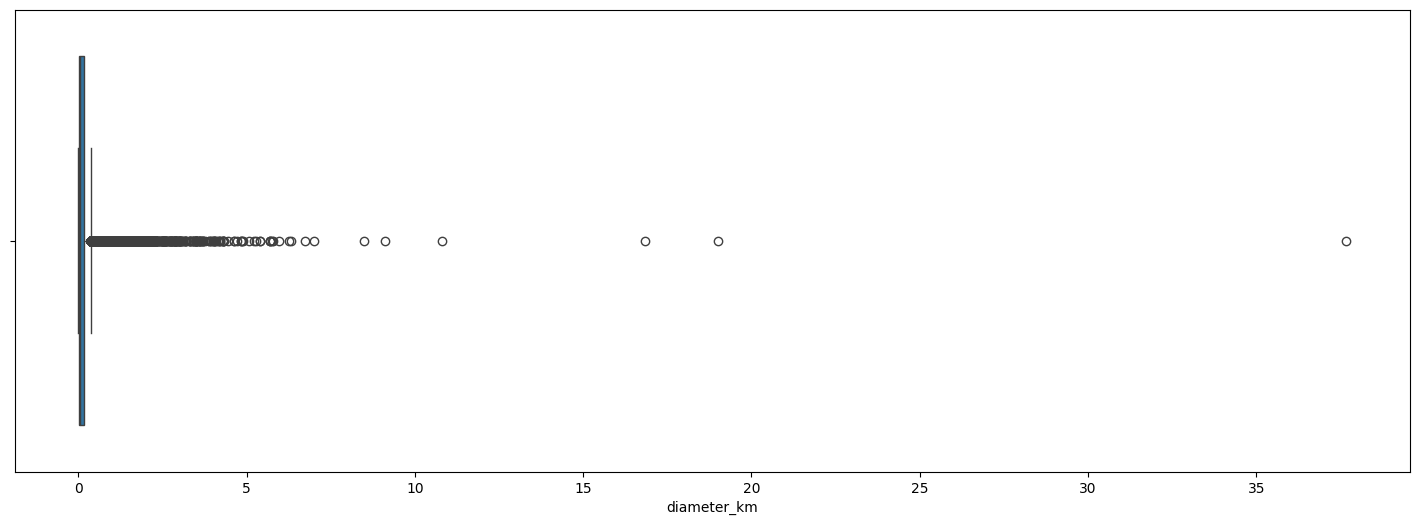

In [ ]:
plt.figure(figsize=(18,6))
sns.boxplot(x=df["diameter_km"])

Text(0.5, 1.0, 'Distribution of the Diameter of the Asteroids')

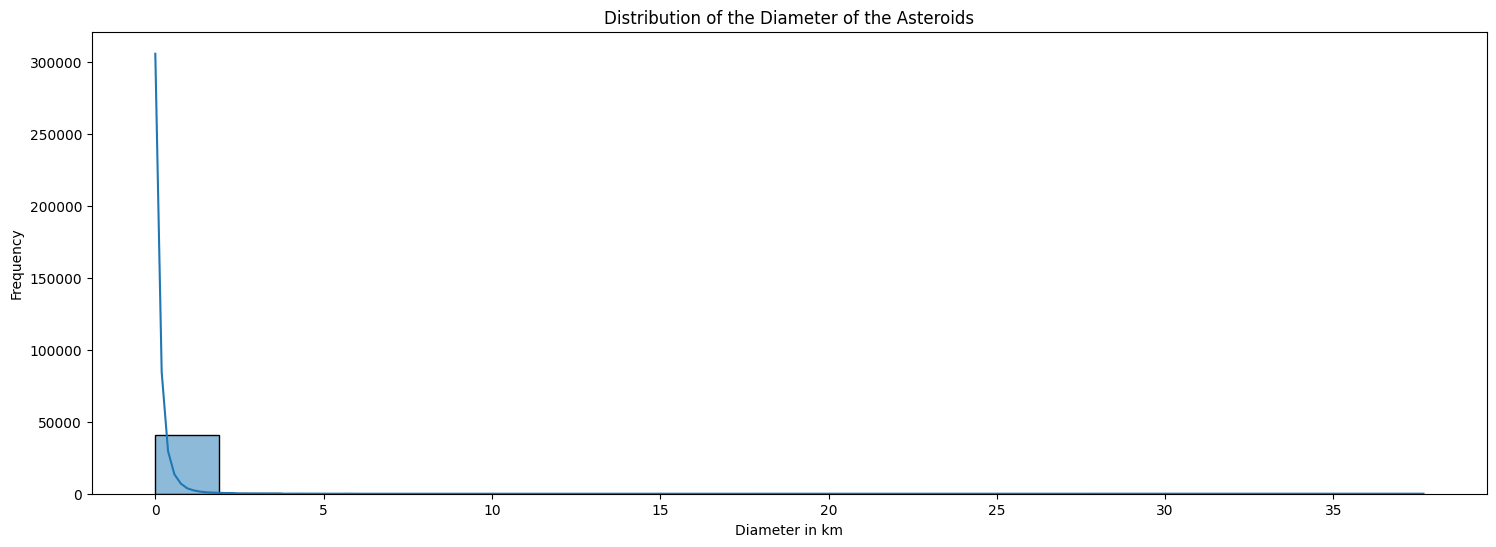

In [ ]:
plt.figure(figsize=(18,6))
sns.histplot(df["diameter_km"], bins=20, kde=True)

plt.xlabel('Diameter in km')
plt.ylabel('Frequency')
plt.title('Distribution of the Diameter of the Asteroids')

The average size of the asteroids is 0.166 km.

The smallest asteroid's diameter is about 0.000475 km, so only 0.5m.

The biggest asteroid's diameter is 37.675km.

From the boxplot, we can see that most of the diameter are lower than 5km. They are pretty much allocated in only one part of the graph.

We have some outliers, only 4 asteroids are above 10km. They must certainly influence the mean a lot.


Futhermore, the histogram definitely confirms what we've said. The curve is skewed to the right.

----

**Question 5 : Is there a relationship between the diameter and the hazardness of an asteroid ?**

In [ ]:
df["pha"].value_counts()

,count
pha,
False,38742
True,2539


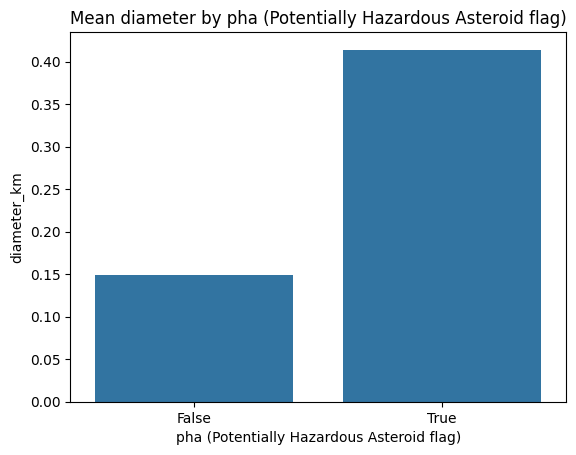

In [ ]:
diameter_km_mean = df.groupby("pha")["diameter_km"].mean().reset_index()

sns.barplot(data=diameter_km_mean,
            x="pha",
            y="diameter_km")
plt.title("Mean diameter by pha (Potentially Hazardous Asteroid flag)")
plt.xlabel("pha (Potentially Hazardous Asteroid flag)")
plt.ylabel("diameter_km")
plt.show()

In [ ]:
df.nlargest(10,"diameter_km")

,spkid,full_name,pdes,pha,magnitude,diameter_km,diameter_m,diameter_is_estimated,size_category,class,...,observation_numbers,condition_code,first_obs,last_obs,data_arc,data_arc_years,distance_per_size,numbersight_per_quality,rotation_per_orbit,hazardness
3,20001036,1036 Ganymed (A924 UB),1036,False,9.17,37.675,37675.0,False,Large (>1 km) — City killer+,AMO,...,0.2266,0.0,1924-10-23,2026-03-22,37040.0,101.41,1.361966e+06,inf,365.517241,True
48,20003552,3552 Don Quixote (1983 SA),3552,False,13.03,19.000,19000.0,False,Large (>1 km) — City killer+,AMO,...,0.1117,0.0,1983-09-10,2026-03-20,15532.0,42.52,2.692762e+06,inf,365.079365,True
0,20000433,433 Eros (A898 PA),433,False,10.39,16.840,16840.0,False,Large (>1 km) — City killer+,AMO,...,0.5598,0.0,1893-10-29,2021-05-13,46582.0,127.53,1.314756e+06,inf,365.340909,True
80,20004954,4954 Eric (1990 SQ),4954,False,12.55,10.800,10800.0,False,Large (>1 km) — City killer+,AMO,...,0.3481,0.0,1975-06-07,2026-03-23,18552.0,50.79,2.687221e+06,inf,363.957597,True
8,20001627,1627 Ivar (1929 SH),1627,False,12.79,9.120,9120.0,False,Large (>1 km) — City killer+,AMO,...,0.3876,0.0,1929-09-25,2025-06-15,34962.0,95.72,1.787957e+06,inf,365.748031,True
14,20001866,1866 Sisyphus (1972 XA),1866,False,12.48,8.480,8480.0,False,Large (>1 km) — City killer+,APO,...,0.3783,0.0,1955-01-26,2026-03-22,25988.0,71.15,1.834691e+06,inf,364.750958,True
286,20053319,53319 (1999 JM8),53319,True,15.35,7.000,7000.0,False,Large (>1 km) — City killer+,APO,...,0.2192,0.0,1999-04-10,2026-03-20,9841.0,26.94,5.599234e+05,inf,364.444444,True
283,20052762,52762 (1998 MT24),52762,False,14.82,6.742,6742.0,False,Large (>1 km) — City killer+,APO,...,0.2625,0.0,1953-10-02,2025-11-29,26356.0,72.16,3.039885e+06,inf,365.333333,True
125,20007092,7092 Cadmus (1992 LC),7092,False,15.12,6.319,6319.0,False,Large (>1 km) — City killer+,APO,...,0.2427,0.0,1980-06-02,2025-07-28,16492.0,45.15,2.391104e+06,inf,364.532020,True
40,20003200,3200 Phaethon (1983 TB),3200,True,14.38,6.250,6250.0,False,Large (>1 km) — City killer+,APO,...,0.6875,0.0,1983-10-27,2026-03-03,15468.0,42.35,4.475968e+05,inf,366.433566,True


To answer this question, we've started by establishing the number of asteroids being hasardous or not. PHA refers to the Potentially Hazardous Asteroid, meaning that if it returns False, it doesn't constitute a danger, but if it returns true, it constitute a danger.

While, it is reassuring to see that less asteroid returns True, it is particulartly interesting to compare it with the size of the asteroids.
Indeed, despite having really fewer hasardous asteroids, they are on average about twice (almost triple) as large as non hasardous ones.
This suggests that larger asteroids are more likely to be classified as potentially hasardous.

However, I've added the top 10 largest asteroids to verify if it is actually the case for them, but only 2 returned true.

----

**Question 6 : What is the relation of hasardness of asteroids with their MOID ?**





/tmp/ipykernel_3220/1852037022.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groupped_pha_moid = df.groupby("moid_interval")["pha"].mean()


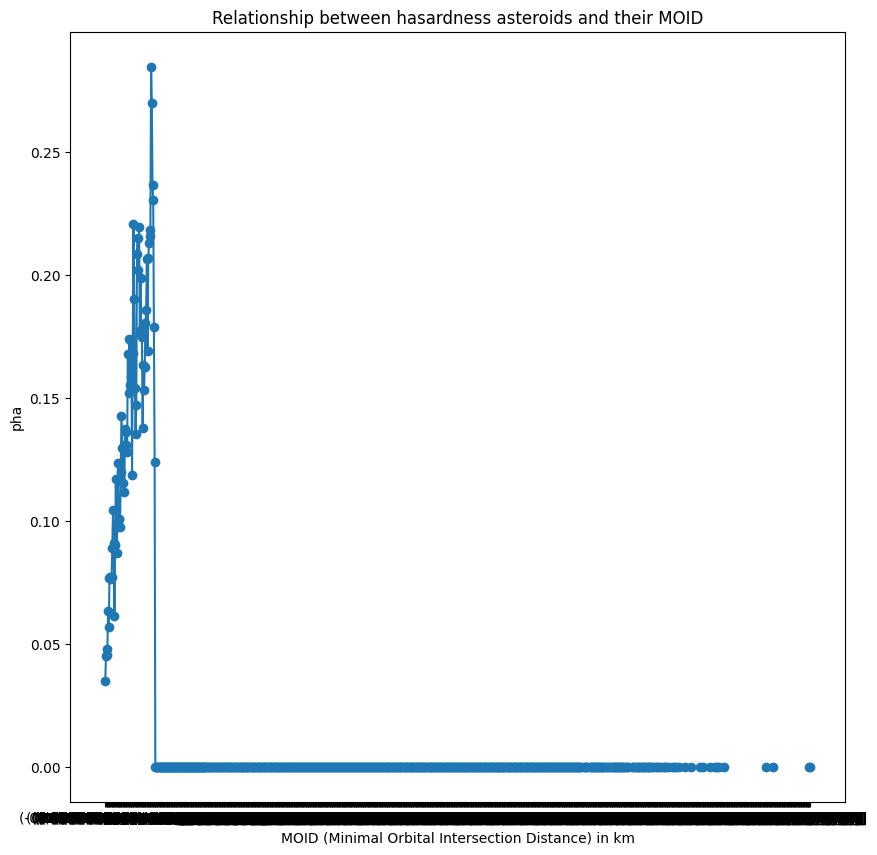

In [ ]:
#Let's create intervals for MOID to enhance the visbility for our analysis
df["moid_interval"] = pd.cut(df["moid_au"], bins=1000)

#We group our pha with their respective moid interval
groupped_pha_moid = df.groupby("moid_interval")["pha"].mean()

plt.figure(figsize=(10,10))
plt.plot(groupped_pha_moid.index.astype(str), groupped_pha_moid.values, marker="o")
plt.title("Relationship between hasardness asteroids and their MOID")
plt.xlabel("MOID (Minimal Orbital Intersection Distance) in km")
plt.ylabel("pha")
plt.show()

This shows clearly that the smallest MOID represent the greatest hasardness for a potential collision with Earth.
In other words, the closer an asteroid comes to Earth, the more dangerous it is.

Note : I tried to take the MOID in km but it was too slow to proceed, so I took MOID in au and it worked.

# 🪐  **FINDINGS**

(All questions contain below their respective codes, their own analysis and display my findings. I believed it was cleaner this way.)


1.   Our first question aimed to assess whether or not there is a correlation between the diameter of an asteroid and its duration of its visibility. The objective was to determine if a greater diameter increased the chances of observing an asteroid. I thought it as particularly useful as a bigger asteroid means more damage in case of a collision, and a greater visibility means that there were higher chances of observing the patterns and therefore avoiding a crisis. We found a correlation of 0.616, which means that there is a correlation positive moderate. It means that as the diameter of the asteroid increases, the duration of their arc around Earth is greater. However, since the correlation is not perfect, the diameter is not the only variable associated to the duration of the visibility of an asteroid.

2.   Our second question aimed to show the 10 asteroids that came the closest to our planet. It was interesting to see that in 2014, we had an asteroid that came as close as only 68km of our planet.

3.   Our third question aimed to analyse the overall correlation along all our variables. We've found a strong positive correlation between the rotation period or orbital period with the aphelion. It shows that the asteroids with larger apheloin generally have a longer orbital and rotation period.
We also have some variables that are greatly inversely correlated between each other, like the condition code and the data_arc, which is characterised with a correlation of -0.72, negative moderate. It means that the asteroids that we've seen the less, are the ones with the most unpredictable orbits. In other words, the visibility of an asteroid is inversely related to the level its orbit unpredictability.


4.   For our third question, we wanted to determine the size of the largest and smallest asteroids, and also the average diameter. Our additional objective was to identify outliers. We've found that the average size of the asteroids is 0.166 km, with a range going from 0.000475 km, so only 0.5m to 37.675km. Furthermore, we have some outliers, only 4 asteroids are above 10km. They must certainly influence the mean a lot. The curve is skewed to the right.

5. Our fifth question aimed to assess the relationship between the size of an asteroid and the danger it represents. To answer this question, we've started by establishing the number of asteroids being hasardous or not. We've found that despite having much fewer hasardous asteroids, they were on average about twice (almost triple) as large as non hasardous ones. This suggested that larger asteroids are more likely to be classified as potentially hasardous.

6. Our final question aimed to analyse the relationship between the hasardness of an asteroid and its MOID. We've found that the smallest MOID represented the greatest hasardness for a potential collision with Earth. In other words, the closer an asteroid comes to Earth, the more danger it represents.


# 🪐  **CONCLUSION**

This project allowed me to analyse the characteristic sof Near-Earth Asteroids. Through Data cleaning and statistical analysis and visualisation, using Python, Pandas, Matplotlib and Seaborn, I was able to identify several important relationships among the variables.

My analyses showed that the larger asteroids have longer observation periods. This is suggesting that the a greater size enhance the chances of detecting big asteroids and monitoring them over time.
This is particularly important considering that despite being 15 times less present in our dataset, the larger asteroids constitute a bigger danger, which is about 3 times bigger than the smallest ones.

Furthermore, asteroids with smaller MOID (Minimal Orbital Intersection Distance)are more likely to be considered as hasardous. This emphasize the importance of orbital proximity when we are evaluting collision risks.

Altough this analysis provided interesting insights, the results found in our correlation analysis highlighted the fact that we need more information as our variables we're not perfectly correlated with the risks. Therefore, additional researches could be explored in future studies, to determine other causations.

I've really enjoyed making this project, particularly as it enabled me to learn a lot of stuffs on a subject that I love. I hope that you found it interesting as well. Have a great day !

